## 1. Imports and Setup


In [ ]:
import os
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import librosa
import warnings
warnings.filterwarnings('ignore')

from tqdm import tqdm
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, accuracy_score, f1_score
)
import tensorflow as tf

SR         = 22050
N_MELS     = 128
N_FFT      = 2048
HOP_LEN    = 512
FMIN       = 20
FMAX       = 8000
N_MFCC     = 40
N_FRAMES   = 128
HOP_FRAMES = 64

CLASSES = [
    'bus', 'busystreet', 'office', 'openairmarket', 'park',
    'quietstreet', 'restaurant', 'supermarket', 'tube', 'tubestation'
]
CLASS_TO_IDX = {cls: idx for idx, cls in enumerate(CLASSES)}

OUTPUT_DIR = 'output_block1'


RESULTS = {
    'E1 Log-Mel+kNN' : {'test_acc': 0.40, 'test_f1': 0.38},
    'E2 Log-Mel+SVM' : {'test_acc': 0.59, 'test_f1': 0.57},
    'E3 MFCC+kNN'    : {'test_acc': 0.60, 'test_f1': 0.59},
    'E4 MFCC+SVM'    : {'test_acc': 0.75, 'test_f1': 0.74},
    'CNN Log-Mel'    : {'test_acc': 0.64, 'test_f1': 0.65},
}

print('Setup complete.')
print(f'Output dir : {os.path.abspath(OUTPUT_DIR)}')
print(f'Models to analyze: {list(RESULTS.keys())}')


Setup complete.
Output dir : c:\Users\34610\Desktop\UNIVERSIDAD\Máster\Integracion tecnologias\Proyecto\output_block1
Models to analyze: ['E1 Log-Mel+kNN', 'E2 Log-Mel+SVM', 'E3 MFCC+kNN', 'E4 MFCC+SVM', 'CNN Log-Mel']


## 2. Final Results Summary


FINAL RESULTS — ALL MODELS (Official DCASE 2013 Test Set)
         Model  Test Accuracy  Test F1 (macro) vs Random (10%) vs Best Baseline
   E4 MFCC+SVM           0.75             0.74           +0.65            +0.00
   CNN Log-Mel           0.64             0.65           +0.54            -0.11
   E3 MFCC+kNN           0.60             0.59           +0.50            -0.15
E2 Log-Mel+SVM           0.59             0.57           +0.49            -0.16
E1 Log-Mel+kNN           0.40             0.38           +0.30            -0.35
Random baseline     : 0.10 (1/10 classes)
DCASE 2013 baseline : ~0.74 (competition system)


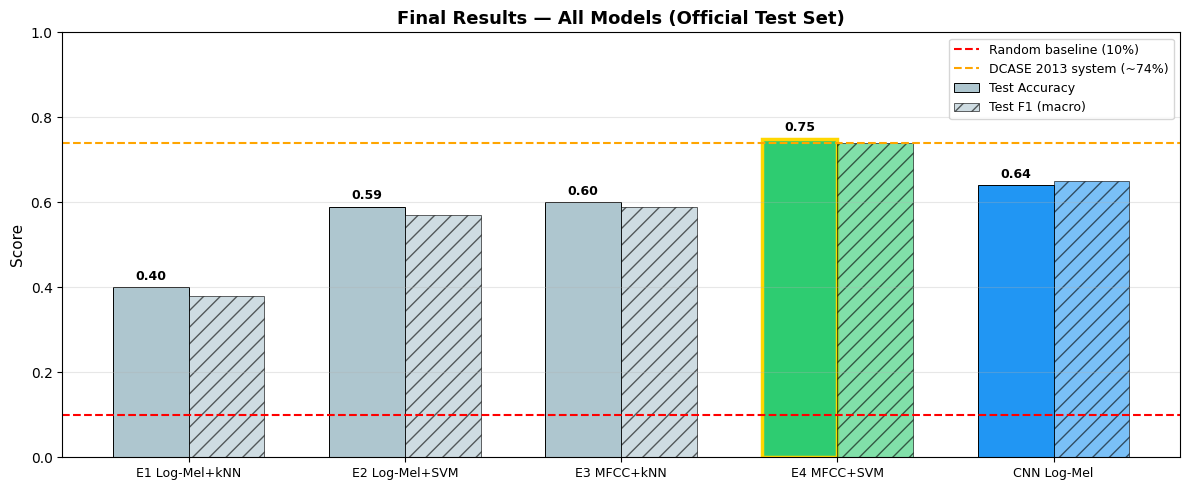

Saved: output_block1\final_results_all_models.png


In [2]:
df_results = pd.DataFrame(RESULTS).T.reset_index()
df_results.columns = ['Model', 'Test Accuracy', 'Test F1 (macro)']
df_results = df_results.sort_values('Test Accuracy', ascending=False)
df_results['vs Random (10%)']  = df_results['Test Accuracy'].apply(lambda x: f'+{x-0.10:.2f}')
df_results['vs Best Baseline'] = df_results['Test Accuracy'].apply(lambda x: f'{x-0.75:+.2f}')

print('=' * 70)
print('FINAL RESULTS — ALL MODELS (Official DCASE 2013 Test Set)')
print('=' * 70)
print(df_results.to_string(index=False))
print('=' * 70)
print(f'Random baseline     : 0.10 (1/10 classes)')
print(f'DCASE 2013 baseline : ~0.74 (competition system)')

fig, ax = plt.subplots(figsize=(12, 5))
models    = list(RESULTS.keys())
test_accs = [RESULTS[m]['test_acc'] for m in models]
test_f1s  = [RESULTS[m]['test_f1']  for m in models]
colors    = ['#aec6cf', '#aec6cf', '#aec6cf', '#2ecc71', '#2196F3']

x     = np.arange(len(models))
width = 0.35

bars1 = ax.bar(x - width/2, test_accs, width, label='Test Accuracy',
               color=colors, edgecolor='black', linewidth=0.7)
bars2 = ax.bar(x + width/2, test_f1s,  width, label='Test F1 (macro)',
               color=colors, edgecolor='black', linewidth=0.7, alpha=0.6, hatch='//')

for bar, val in zip(bars1, test_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.axhline(0.10, color='red',    linestyle='--', linewidth=1.5, label='Random baseline (10%)')
ax.axhline(0.74, color='orange', linestyle='--', linewidth=1.5, label='DCASE 2013 system (~74%)')
ax.set_title('Final Results — All Models (Official Test Set)', fontsize=13, fontweight='bold')
ax.set_ylabel('Score', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=9)
ax.set_ylim(0, 1.0)
ax.legend(fontsize=9)
ax.grid(True, axis='y', alpha=0.3)

best_idx = np.argmax(test_accs)
bars1[best_idx].set_edgecolor('gold')
bars1[best_idx].set_linewidth(2.5)

plt.tight_layout()
out_path = os.path.join(OUTPUT_DIR, 'final_results_all_models.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path}')


## 3. Load Models and Predictions for Detailed Analysis




In [3]:
# ── Best baseline: E4 MFCC + SVM ────────────────────────────────────────────
with open(os.path.join(OUTPUT_DIR, 'best_baseline_model.pkl'), 'rb') as f:
    best_baseline = pickle.load(f)

with open(os.path.join(OUTPUT_DIR, 'scaler_mfcc.pkl'), 'rb') as f:
    scaler_mfcc = pickle.load(f)

# ── CNN model y estadísticas de normalización ─────────────────────────────────
cnn_model   = tf.keras.models.load_model(os.path.join(OUTPUT_DIR, 'cnn_asc_model.keras'))
global_mean = np.load(os.path.join(OUTPUT_DIR, 'cnn_global_mean.npy'))
global_std  = np.load(os.path.join(OUTPUT_DIR, 'cnn_global_std.npy'))

print('Models loaded successfully.')
print(f'Best baseline : {type(best_baseline).__name__}')
print(f'CNN model     : {cnn_model.name}')


Models loaded successfully.
Best baseline : SVC
CNN model     : sequential_11


## 4. Preprocessing and Test Set Predictions




In [ ]:
def preprocess_audio(filepath):
    wav, _ = librosa.load(filepath, sr=SR, mono=True)
    return wav / (np.max(np.abs(wav)) + 1e-9)

def extract_mfcc_features(wav):
    mfcc = librosa.feature.mfcc(
        y=wav, sr=SR, n_mfcc=N_MFCC,
        n_fft=N_FFT, hop_length=HOP_LEN, fmin=FMIN, fmax=FMAX
    )
    return np.concatenate([np.mean(mfcc, axis=1), np.std(mfcc, axis=1)])

def extract_logmel_spectrogram(wav):
    mel = librosa.feature.melspectrogram(
        y=wav, sr=SR, n_mels=N_MELS,
        n_fft=N_FFT, hop_length=HOP_LEN, fmin=FMIN, fmax=FMAX
    )
    return librosa.power_to_db(mel, ref=np.max).T

def segment_spectrogram(spec):
    segments = []
    for start in range(0, spec.shape[0] - N_FRAMES + 1, HOP_FRAMES):
        segments.append(spec[start:start + N_FRAMES])
    return np.array(segments)


TEST_PATH = r'C:\Users\34610\Desktop\UNIVERSIDAD\Máster\Integracion tecnologias\Proyecto\scenes_stereo_testset'  

test_records = []
for filename in sorted(os.listdir(TEST_PATH)):
    if not filename.endswith('.wav'):
        continue
    label = re.sub(r'\d+$', '', os.path.splitext(filename)[0])
    if label not in CLASS_TO_IDX:
        continue
    test_records.append({
        'filename' : filename,
        'filepath' : os.path.join(TEST_PATH, filename),
        'label'    : label,
        'label_idx': CLASS_TO_IDX[label]
    })

df_test = pd.DataFrame(test_records)
print(f'Test files: {len(df_test)}')
print(df_test['label'].value_counts().sort_index())


Test files: 100
label
bus              10
busystreet       10
office           10
openairmarket    10
park             10
quietstreet      10
restaurant       10
supermarket      10
tube             10
tubestation      10
Name: count, dtype: int64


In [5]:
y_true, y_pred_svm, y_pred_cnn = [], [], []

for _, row in tqdm(df_test.iterrows(), total=len(df_test), desc='Predicting'):
    wav = preprocess_audio(row['filepath'])

    # SVM: MFCC features
    mfcc_vec = extract_mfcc_features(wav).reshape(1, -1)
    svm_pred = best_baseline.predict(scaler_mfcc.transform(mfcc_vec))[0]

    # CNN: score fusion sobre segmentos
    spec     = extract_logmel_spectrogram(wav)
    segs     = segment_spectrogram(spec)
    segs     = ((segs - global_mean) / (global_std + 1e-9))[..., np.newaxis].astype(np.float32)
    cnn_pred = np.argmax(cnn_model.predict(segs, verbose=0).mean(axis=0))

    y_true.append(row['label_idx'])
    y_pred_svm.append(svm_pred)
    y_pred_cnn.append(cnn_pred)

y_true     = np.array(y_true)
y_pred_svm = np.array(y_pred_svm)
y_pred_cnn = np.array(y_pred_cnn)

print(f'SVM accuracy : {accuracy_score(y_true, y_pred_svm):.4f}')
print(f'CNN accuracy : {accuracy_score(y_true, y_pred_cnn):.4f}')


Predicting: 100%|██████████| 100/100 [00:20<00:00,  4.84it/s]

SVM accuracy : 0.7500
CNN accuracy : 0.6400


## 5. Comparative Confusion Matrices




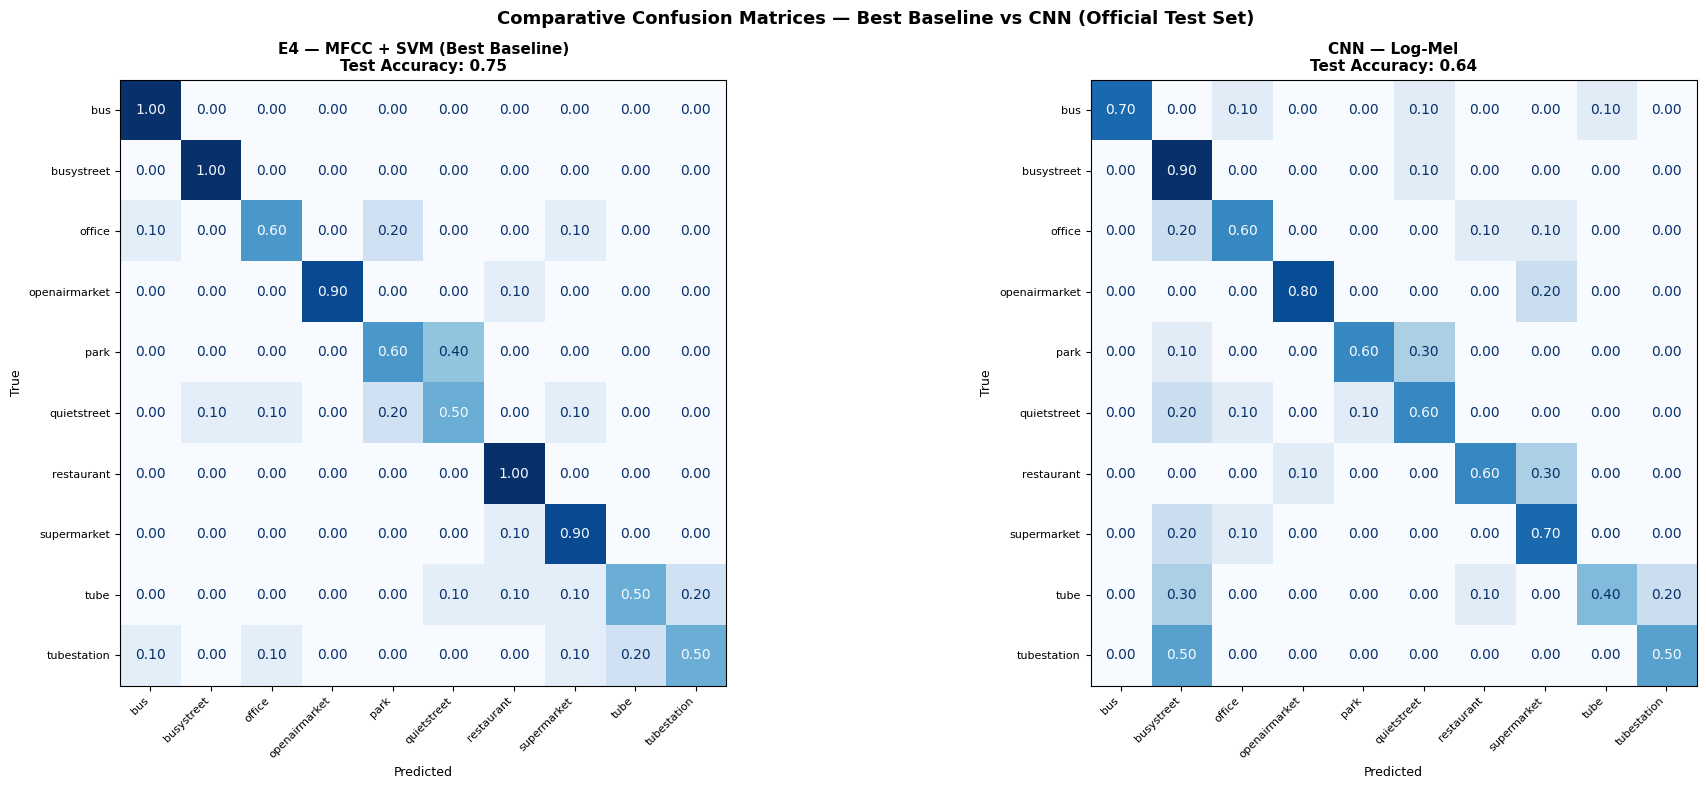

Saved: output_block1\comparative_confusion_matrices.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

svm_acc = accuracy_score(y_true, y_pred_svm)
cnn_acc = accuracy_score(y_true, y_pred_cnn)

for ax, y_pred, title, acc in zip(
    axes,
    [y_pred_svm, y_pred_cnn],
    ['E4 — MFCC + SVM (Best Baseline)', 'CNN — Log-Mel'],
    [svm_acc, cnn_acc]
):
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
    disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='.2f')
    ax.set_title(f'{title}\nTest Accuracy: {acc:.2f}', fontsize=11, fontweight='bold')
    ax.set_xticklabels(CLASSES, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(CLASSES, fontsize=8)
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('True', fontsize=9)

fig.suptitle('Comparative Confusion Matrices — Best Baseline vs CNN (Official Test Set)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
out_path = os.path.join(OUTPUT_DIR, 'comparative_confusion_matrices.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path}')


## 6. Per-Class Analysis — SVM vs CNN


Class             SVM F1   CNN F1     Diff   Winner
-------------------------------------------------------
bus                0.909    0.824   -0.086    SVM ↑
busystreet         0.952    0.529   -0.423    SVM ↑
office             0.667    0.632   -0.035      TIE
openairmarket      0.947    0.842   -0.105    SVM ↑
park               0.600    0.706   +0.106    CNN ↑
quietstreet        0.500    0.571   +0.071    CNN ↑
restaurant         0.870    0.667   -0.203    SVM ↑
supermarket        0.783    0.609   -0.174    SVM ↑
tube               0.588    0.533   -0.055    SVM ↑
tubestation        0.588    0.588   +0.000      TIE
-------------------------------------------------------
MACRO AVG          0.740    0.650   -0.090


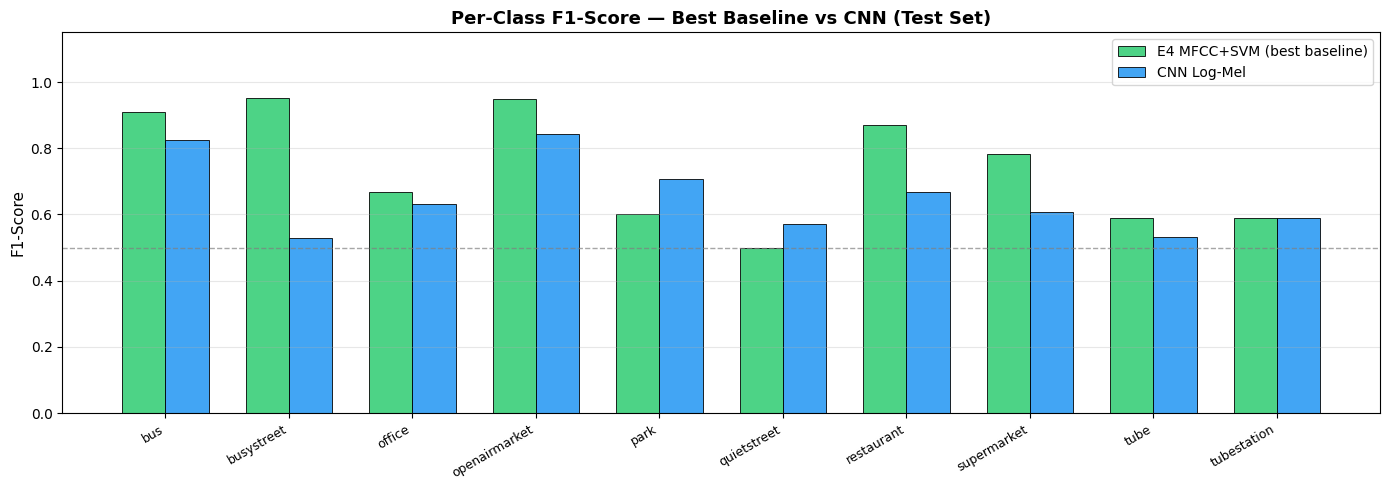

Saved: output_block1\perclass_f1_comparison.png


In [7]:
report_svm = classification_report(y_true, y_pred_svm, target_names=CLASSES, output_dict=True)
report_cnn = classification_report(y_true, y_pred_cnn, target_names=CLASSES, output_dict=True)

f1_svm = [report_svm[cls]['f1-score'] for cls in CLASSES]
f1_cnn = [report_cnn[cls]['f1-score'] for cls in CLASSES]
diff   = [c - s for c, s in zip(f1_cnn, f1_svm)]

print(f'{"Class":<15} {"SVM F1":>8} {"CNN F1":>8} {"Diff":>8} {"Winner":>8}')
print('-' * 55)
for cls, s, c, d in zip(CLASSES, f1_svm, f1_cnn, diff):
    winner = 'CNN ↑' if d > 0.05 else ('SVM ↑' if d < -0.05 else 'TIE')
    print(f'{cls:<15} {s:>8.3f} {c:>8.3f} {d:>+8.3f} {winner:>8}')
print('-' * 55)
print(f'{"MACRO AVG":<15} {np.mean(f1_svm):>8.3f} {np.mean(f1_cnn):>8.3f} '
      f'{np.mean(f1_cnn)-np.mean(f1_svm):>+8.3f}')

x     = np.arange(len(CLASSES))
width = 0.35
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width/2, f1_svm, width, label='E4 MFCC+SVM (best baseline)',
       color='#2ecc71', edgecolor='black', linewidth=0.7, alpha=0.85)
ax.bar(x + width/2, f1_cnn, width, label='CNN Log-Mel',
       color='#2196F3', edgecolor='black', linewidth=0.7, alpha=0.85)

ax.set_title('Per-Class F1-Score — Best Baseline vs CNN (Test Set)', fontsize=13, fontweight='bold')
ax.set_ylabel('F1-Score', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(CLASSES, rotation=30, ha='right', fontsize=9)
ax.set_ylim(0, 1.15)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.legend(fontsize=10)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
out_path = os.path.join(OUTPUT_DIR, 'perclass_f1_comparison.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path}')


## 7. Error Analysis

### 7.1 Most Confused Class Pairs


In [8]:
def get_confusion_pairs(y_true, y_pred, classes, top_n=5):
    cm = confusion_matrix(y_true, y_pred)
    pairs = []
    for i in range(len(classes)):
        for j in range(len(classes)):
            if i != j and cm[i, j] > 0:
                pairs.append({
                    'True'      : classes[i],
                    'Predicted' : classes[j],
                    'Count'     : cm[i, j],
                    'Rate'      : cm[i, j] / cm[i].sum()
                })
    return pd.DataFrame(pairs).sort_values('Count', ascending=False).head(top_n)


print('TOP CONFUSION PAIRS — E4 MFCC + SVM')
print(get_confusion_pairs(y_true, y_pred_svm, CLASSES).to_string(index=False))
print()
print('TOP CONFUSION PAIRS — CNN Log-Mel')
print(get_confusion_pairs(y_true, y_pred_cnn, CLASSES).to_string(index=False))


TOP CONFUSION PAIRS — E4 MFCC + SVM
       True   Predicted  Count  Rate
       park quietstreet      4   0.4
     office        park      2   0.2
tubestation        tube      2   0.2
quietstreet        park      2   0.2
       tube tubestation      2   0.2

TOP CONFUSION PAIRS — CNN Log-Mel
       True   Predicted  Count  Rate
tubestation  busystreet      5   0.5
       tube  busystreet      3   0.3
 restaurant supermarket      3   0.3
       park quietstreet      3   0.3
     office  busystreet      2   0.2


### 7.2 Acoustic Interpretation of Confusions


In [9]:
acoustic_groups = {
    'Underground environments\n(shared: reverb, machinery, PA)': ['tube', 'tubestation'],
    'Quiet outdoor environments\n(shared: low energy, ambient)': ['park', 'quietstreet'],
    'Indoor social environments\n(shared: voices, background noise)': ['office', 'restaurant', 'supermarket'],
    'Busy outdoor environments\n(shared: traffic, crowds)': ['busystreet', 'openairmarket'],
}

print('ACOUSTIC CONFUSION GROUPS')
print('=' * 60)
cm_svm = confusion_matrix(y_true, y_pred_svm)
for group, group_classes in acoustic_groups.items():
    print(f'\n{group}')
    print(f'  Classes: {group_classes}')
    for c1 in group_classes:
        for c2 in group_classes:
            if c1 != c2:
                i, j = CLASSES.index(c1), CLASSES.index(c2)
                rate = cm_svm[i, j] / cm_svm[i].sum() if cm_svm[i].sum() > 0 else 0
                if rate > 0:
                    print(f'  {c1} → {c2}: {rate:.0%} confusion rate (SVM)')


ACOUSTIC CONFUSION GROUPS

Underground environments
(shared: reverb, machinery, PA)
  Classes: ['tube', 'tubestation']
  tube → tubestation: 20% confusion rate (SVM)
  tubestation → tube: 20% confusion rate (SVM)

Quiet outdoor environments
(shared: low energy, ambient)
  Classes: ['park', 'quietstreet']
  park → quietstreet: 40% confusion rate (SVM)
  quietstreet → park: 20% confusion rate (SVM)

Indoor social environments
(shared: voices, background noise)
  Classes: ['office', 'restaurant', 'supermarket']
  office → supermarket: 10% confusion rate (SVM)
  supermarket → restaurant: 10% confusion rate (SVM)

Busy outdoor environments
(shared: traffic, crowds)
  Classes: ['busystreet', 'openairmarket']
